In [2]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# extract data from root file
file = uproot.open("Na22Decay.root")
tree = file["Ideal;1"]
data = tree.arrays(library="pd")

/home/eltisau/software/miniconda3/envs/MG5/lib/python3.13/site-packages/awkward_pandas/array.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(ak.is_none(self._data))


Particle: e+, Count: 90008
Particle: nu_e, Count: 100000
Particle: gamma, Count: 100065
Particle: e-, Count: 9039


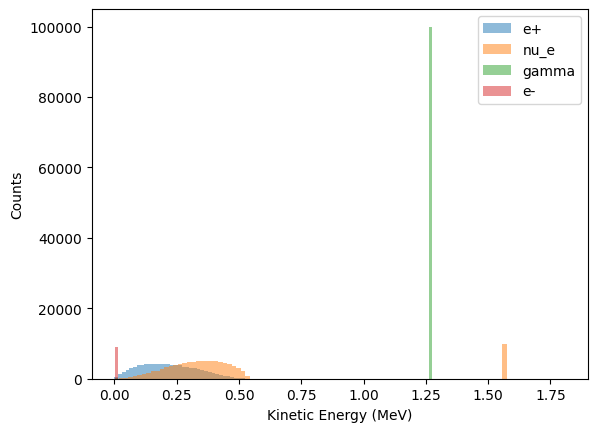

In [8]:
for particle in data['ParticleName'].unique():
    subset = data[data['ParticleName'] == particle]
    print(f"Particle: {particle}, Count: {len(subset)}")
    plt.hist(subset['KineticEnergy_MeV'], bins=100, alpha=0.5, label=particle)
    plt.legend()
    plt.xlabel("Kinetic Energy (MeV)")
    plt.ylabel("Counts")

/home/eltisau/software/miniconda3/envs/MG5/lib/python3.13/site-packages/awkward_pandas/array.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(ak.is_none(self._data))


<Axes: ylabel='Frequency'>

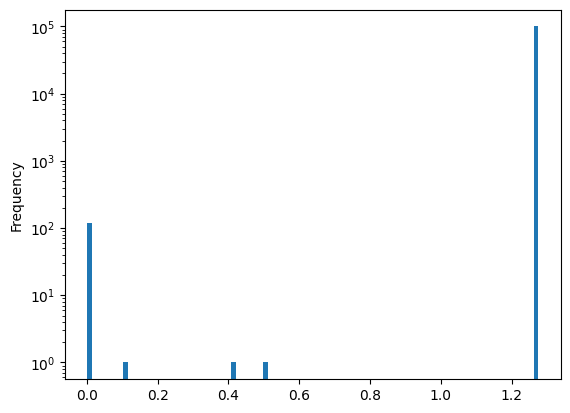

In [17]:
data[data['ParticleName'] == 'gamma']['KineticEnergy_MeV'].plot.hist(bins=100,log=True)


In [22]:
(data[data['ParticleName'] == 'gamma']['KineticEnergy_MeV']>1.0).sum()

np.int64(99945)

- Perfect Neutrino Match: 100,000 nu_e exactly equals total events, confirming one neutrino per decay in both β⁺ and EC branches, validating weak interaction modeling.
- Positron Branching: ~90% e+ count (90,008) aligns with known β⁺ ratio (~89.89-90%), with energy spectrum showing expected hump and endpoint (~0.545 MeV), proving accurate sampling of allowed transitions.
- Gamma De-Excitation: Near-100% gamma (100,065) with sharp 1.275 MeV peak matches Ne-22* emission in ~99.9% decays, including minor excess from secondaries, affirming nuclear level handling.
- Electron from EC: ~9% e- (9,039) from Auger cascades in ~10% EC branch, with low-energy hump (<0.1 MeV), correctly modeled under "RadioactiveDecay" process, ruling out unintended pair production in this setup.